Đã đọc ảnh thành công: image/noise_hoa.jpg
Kích thước ảnh: 540 x 960 | Số kênh màu: 3
>>> PHÂN LOẠI: Ảnh MÀU  => Tiến hành tách thành 3 ma trận độc lập R, G, B

-> Đã xuất toàn bộ dữ liệu ma trận ảnh (540x960) ra thư mục gốc 'ma_tran_day_du/'
--- Kênh R: Phân tích SVD xong | Tổng số giá trị kỳ dị = 540
--- Kênh G: Phân tích SVD xong | Tổng số giá trị kỳ dị = 540
--- Kênh B: Phân tích SVD xong | Tổng số giá trị kỳ dị = 540

>>> K TỐI ƯU TỰ ĐỘNG CHỌN (Ngưỡng 98% năng lượng): k = 131

    k |       MSE | PSNR(dB) |    SSIM | Tỷ lệ nén |   Chuẩn Frob Error
   20 |    552.90 |    20.70 |   0.323 |     17.3x |           29317.81
   50 |    358.32 |    22.59 |   0.589 |      6.9x |           23609.61
  100 |    177.50 |    25.64 |   0.814 |      3.5x |           16640.11
  131 |    109.07 |    27.75 |   0.890 |      2.6x |           13053.82  <-- K TỐI ƯU
  150 |     78.25 |    29.20 |   0.922 |      2.3x |           11056.98
  250 |      4.44 |    41.65 |   0.996 |      1.4x |            254

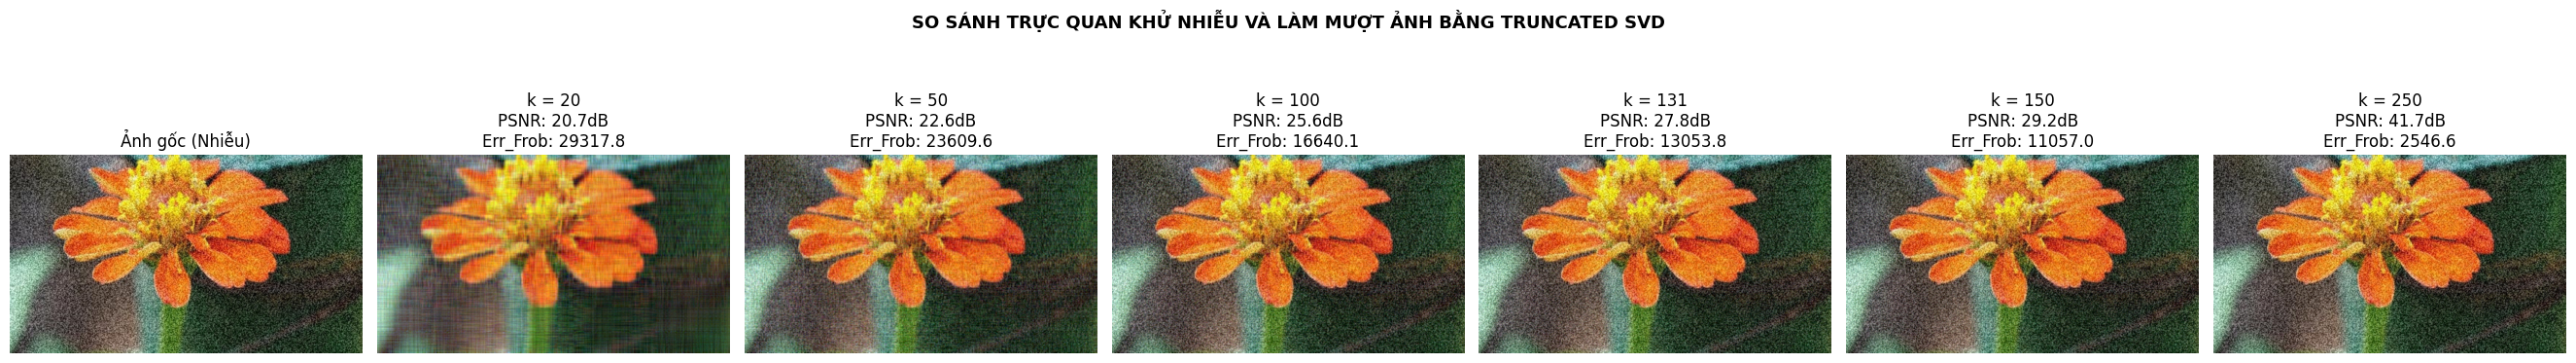

BÁO CÁO KẾT QUẢ ĐỊNH LƯỢNG TẠI ĐIỂM TỐI ƯU NHẤT (k = 131)
  + Sai số toàn phương trung bình (MSE) : 109.075
  + Tỉ số tín hiệu cực đại trên nhiễu (PSNR) : 27.75 dB
  + Chỉ số tương đồng cấu trúc (SSIM)   : 0.8899
  + Tỷ lệ nén dữ liệu hình ảnh (CR)     : 2.64x
  + Sai số Định lượng chuẩn Frobenius   : 13053.82

-> Đã xuất và lưu hình so sánh đôi thành công tại: ket_qua_svd\noise_hoa_K_TOI_UU_so_sanh_doi.png


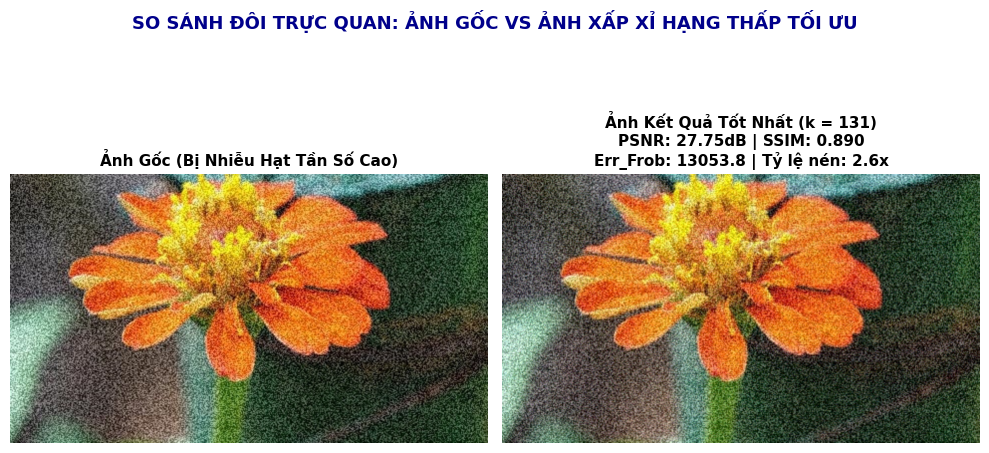

In [16]:
"""
ĐỀ TÀI 4: PHÂN TÍCH SVD VÀ ỨNG DỤNG TRONG XỬ LÝ ẢNH
Đáp ứng đầy đủ: Phân tích định lượng (Chuẩn Frobenius) + Trực quan khử nhiễu + So sánh Gốc vs Tốt nhất.
Chạy trực tiếp trên Jupyter Notebook (.ipynb)
"""

# ==================== TỰ ĐỘNG CÀI THƯ VIỆN NẾU THIẾU ====================
try:
    import skimage
    import numpy
    import PIL
    import matplotlib
except ModuleNotFoundError:
    print("Hệ thống đang cài đặt các thư viện cần thiết...")
    %pip install scikit-image numpy pillow matplotlib

# Cấu hình hiển thị đồ thị của matplotlib ngay trong Notebook
%matplotlib inline

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim


# ==================== CẤU HÌNH HỆ THỐNG ====================
IMAGE_PATH = "image/noise_hoa.jpg"         # <-- Đường dẫn đến file ảnh của bạn
K_VALUES = [20, 50, 100, 150, 250]  # <-- Tăng dải k để giữ lại chi tiết sắc nét cho ảnh màu
NGUONG_NANG_LUONG = 0.98            # <-- Nâng lên 98% năng lượng để ảnh tốt nhất nét căng, không bị nhòe
OUTPUT_DIR = "ket_qua_svd"
MATRIX_DIR = "ma_tran_day_du"
# ===========================================================


def buoc1_doc_anh(path):
    """Đọc ảnh đầu vào và chuyển thành mảng số thực."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file ảnh '{path}'. Bạn hãy kiểm tra lại xem ảnh đã đặt đúng tên và nằm cùng thư mục với file .ipynb chưa nhé!")
        
    img_pil = Image.open(path)
    img = np.array(img_pil, dtype=float)

    if img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]

    print("=" * 75)
    print(f"Đã đọc ảnh thành công: {path}")
    print(f"Kích thước ảnh: {img.shape[0]} x {img.shape[1]} | Số kênh màu: {img.shape[2] if img.ndim == 3 else 1}")
    print("=" * 75)
    return img


def buoc2_phan_biet_xam_mau(img):
    """Phân biệt ảnh xám hay ảnh màu (kể cả trường hợp ảnh xám lưu dưới dạng 3 kênh RGB)."""
    if img.ndim == 2:
        is_color = False
    elif img.ndim == 3 and img.shape[2] == 3:
        is_color = not (
            np.array_equal(img[:, :, 0], img[:, :, 1])
            and np.array_equal(img[:, :, 1], img[:, :, 2])
        )
    else:
        raise ValueError(f"Định dạng ảnh không hỗ trợ, shape = {img.shape}")

    if is_color:
        print(">>> PHÂN LOẠI: Ảnh MÀU  => Tiến hành tách thành 3 ma trận độc lập R, G, B\n")
    else:
        print(">>> PHÂN LOẠI: Ảnh XÁM  => Tiến hành tạo ra 1 ma trận cường độ sáng A\n")
    return is_color


def buoc3_tach_ma_tran(img, is_color):
    """Tách ảnh thành ma trận các kênh tương ứng và xuất dữ liệu thô ra file CSV."""
    if is_color:
        channels = [img[:, :, 0], img[:, :, 1], img[:, :, 2]]
        channel_names = ["R", "G", "B"]
    else:
        A = img[:, :, 0] if img.ndim == 3 else img
        channels = [A]
        channel_names = ["A"]

    m, n = channels[0].shape
    os.makedirs(MATRIX_DIR, exist_ok=True)
    for ch, name in zip(channels, channel_names):
        csv_path = os.path.join(MATRIX_DIR, f"ma_tran_{name}_{m}x{n}.csv")
        np.savetxt(csv_path, ch, delimiter=",", fmt="%.4f")
    print(f"-> Đã xuất toàn bộ dữ liệu ma trận ảnh ({m}x{n}) ra thư mục gốc '{MATRIX_DIR}/'")
    return channels, channel_names, m, n


def buoc4_svd(channels, channel_names):
    """Phân tích SVD thành phần cho từng ma trận kênh."""
    U_list, S_list, Vt_list = [], [], []
    for ch, name in zip(channels, channel_names):
        U, S, Vt = np.linalg.svd(ch, full_matrices=False)
        U_list.append(U)
        S_list.append(S)
        Vt_list.append(Vt)
        print(f"--- Kênh {name}: Phân tích SVD xong | Tổng số giá trị kỳ dị = {len(S)}")
    print()
    return U_list, S_list, Vt_list


def buoc5_tim_k_toi_uu(S_list, channel_names, nguong):
    """Tự động xác định giá trị k tối ưu dựa vào phân bổ năng lượng trị kỳ dị."""
    k_toi_uu_per_channel = []
    for S, name in zip(S_list, channel_names):
        energy_cumsum = np.cumsum(S ** 2) / np.sum(S ** 2)
        idx_can_thiet = np.searchsorted(energy_cumsum, nguong) + 1
        k_toi_uu_per_channel.append(idx_can_thiet)

    k_toi_uu = int(max(k_toi_uu_per_channel))
    print(f">>> K TỐI ƯU TỰ ĐỘNG CHỌN (Ngưỡng {nguong*100:.0f}% năng lượng): k = {k_toi_uu}\n")
    return k_toi_uu


def low_rank_approx(U, S, Vt, k):
    """Công thức toán học Truncated SVD chuẩn: Ak = Uk * Sk * Vk^T"""
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]


def buoc6_tai_tao_anh(U_list, S_list, Vt_list, k_values, is_color):
    """Tái tạo ảnh ở từng mức hạng k khác nhau."""
    ket_qua_anh = []
    for k in k_values:
        approx_channels = [
            low_rank_approx(U, S, Vt, k) for U, S, Vt in zip(U_list, S_list, Vt_list)
        ]
        if is_color:
            Ak_full = np.stack(approx_channels, axis=2)
        else:
            Ak_full = approx_channels[0]

        Ak_full = np.clip(Ak_full, 0, 255).astype(np.uint8)
        ket_qua_anh.append(Ak_full)
    return ket_qua_anh


def buoc7_danh_gia_dinh_luong(img_goc_uint8, ket_qua_anh, k_values, m, n, so_kenh_luu, is_color, idx_k_toi_uu, S_list):
    """
    ĐÁP ỨNG GHI CHÚ ĐỀ BÀI: Phân tích định lượng kết hợp Chuẩn Frobenius
    Tính toán dựa theo định lý Eckart-Young: ||A - Ak||_F = sqrt(sum(sigma_i^2)) từ i=k+1 đến r
    """
    mse_list, psnr_list, ssim_list, cr_list, frob_err_list = [], [], [], [], []

    print(f"{'k':>5} | {'MSE':>9} | {'PSNR(dB)':>8} | {'SSIM':>7} | {'Tỷ lệ nén':>9} | {'Chuẩn Frob Error':>18}")
    print("=" * 75)

    for idx, k in enumerate(k_values):
        Ak_full = ket_qua_anh[idx]

        err = img_goc_uint8.astype(float) - Ak_full.astype(float)
        mse_val = float(np.mean(err ** 2))
        psnr_val = 10 * np.log10((255.0 ** 2) / mse_val) if mse_val > 0 else float("inf")

        if is_color:
            ssim_val = ssim(img_goc_uint8, Ak_full, channel_axis=2)
        else:
            ssim_val = ssim(img_goc_uint8, Ak_full)

        cr_val = (m * n * so_kenh_luu) / (k * (m + n + 1) * so_kenh_luu)

        frob_err_sq = 0
        for S in S_list:
            if k < len(S):
                frob_err_sq += np.sum(S[k:] ** 2)
        frob_err_val = np.sqrt(frob_err_sq)

        mse_list.append(mse_val)
        psnr_list.append(psnr_val)
        ssim_list.append(ssim_val)
        cr_list.append(cr_val)
        frob_err_list.append(frob_err_val)

        danh_dau = "  <-- K TỐI ƯU" if idx == idx_k_toi_uu else ""
        print(f"{k:>5} | {mse_val:>9.2f} | {psnr_val:>8.2f} | {ssim_val:>7.3f} | {cr_val:>8.1f}x | {frob_err_val:>18.2f}{danh_dau}")

    print("=" * 75 + "\n")
    return mse_list, psnr_list, ssim_list, cr_list, frob_err_list


def buoc8_so_sanh_truc_quan(img_goc_uint8, ket_qua_anh, k_values, psnr_list, frob_err_list, is_color, ten_file):
    """Hiển thị chuỗi ảnh so sánh đa mức hạng k để phân tích trực quan khả năng mượt ảnh."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    cmap = None if is_color else "gray"

    n_plots = len(k_values) + 1
    fig, axes = plt.subplots(1, n_plots, figsize=(3.8 * n_plots, 4))

    if n_plots == 1:
        axes = [axes]

    axes[0].imshow(img_goc_uint8, cmap=cmap)
    axes[0].set_title("Ảnh gốc (Nhiễu)")
    axes[0].axis("off")

    for idx, (ax, k, Ak_full, psnr_val) in enumerate(zip(axes[1:], k_values, ket_qua_anh, psnr_list)):
        ax.imshow(Ak_full, cmap=cmap)
        ax.set_title(f"k = {k}\nPSNR: {psnr_val:.1f}dB\nErr_Frob: {frob_err_list[idx]:.1f}")
        ax.axis("off")

    plt.suptitle("SO SÁNH TRỰC QUAN KHỬ NHIỄU VÀ LÀM MƯỢT ẢNH BẰNG TRUNCATED SVD", y=1.08, fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    plt.savefig(os.path.join(OUTPUT_DIR, f"{ten_file}_so_sanh_da_muc_k.png"), dpi=150, bbox_inches='tight')
    plt.show()


def buoc9_so_sanh_goc_vs_toi_uu(img_goc_uint8, ket_qua_anh, idx_k_toi_uu, k_toi_uu,
                                mse_list, psnr_list, ssim_list, cr_list, frob_err_list,
                                is_color, ten_file):
    """Vẽ và lưu riêng hình so sánh đôi chất lượng cao giữa Ảnh gốc vs Ảnh tối ưu tốt nhất."""
    anh_toi_uu = ket_qua_anh[idx_k_toi_uu]
    cmap = None if is_color else "gray"

    print("=" * 75)
    print(f"BÁO CÁO KẾT QUẢ ĐỊNH LƯỢNG TẠI ĐIỂM TỐI ƯU NHẤT (k = {k_toi_uu})")
    print("=" * 75)
    print(f"  + Sai số toàn phương trung bình (MSE) : {mse_list[idx_k_toi_uu]:.3f}")
    print(f"  + Tỉ số tín hiệu cực đại trên nhiễu (PSNR) : {psnr_list[idx_k_toi_uu]:.2f} dB")
    print(f"  + Chỉ số tương đồng cấu trúc (SSIM)   : {ssim_list[idx_k_toi_uu]:.4f}")
    print(f"  + Tỷ lệ nén dữ liệu hình ảnh (CR)     : {cr_list[idx_k_toi_uu]:.2f}x")
    print(f"  + Sai số Định lượng chuẩn Frobenius   : {frob_err_list[idx_k_toi_uu]:.2f}")
    print("=" * 75 + "\n")

    out_img_path = os.path.join(OUTPUT_DIR, f"{ten_file}_K_TOI_UU_KHI_KHU_NHIEU.png")
    Image.fromarray(anh_toi_uu).save(out_img_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(img_goc_uint8, cmap=cmap)
    axes[0].set_title("Ảnh Gốc (Bị Nhiễu Hạt Tần Số Cao)", fontsize=11, fontweight='bold')
    axes[0].axis("off")

    axes[1].imshow(anh_toi_uu, cmap=cmap)
    axes[1].set_title(
        f"Ảnh Kết Quả Tốt Nhất (k = {k_toi_uu})\n"
        f"PSNR: {psnr_list[idx_k_toi_uu]:.2f}dB | SSIM: {ssim_list[idx_k_toi_uu]:.3f}\n"
        f"Err_Frob: {frob_err_list[idx_k_toi_uu]:.1f} | Tỷ lệ nén: {cr_list[idx_k_toi_uu]:.1f}x",
        fontsize=11, fontweight='bold'
    )
    axes[1].axis("off")

    plt.suptitle(f"SO SÁNH ĐÔI TRỰC QUAN: ẢNH GỐC VS ẢNH XẤP XỈ HẠNG THẤP TỐI ƯU", 
                 y=1.06, fontsize=13, fontweight='bold', color='darkblue')
    plt.tight_layout()
    
    fig_path = os.path.join(OUTPUT_DIR, f"{ten_file}_K_TOI_UU_so_sanh_doi.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"-> Đã xuất và lưu hình so sánh đôi thành công tại: {fig_path}")
    plt.show()


def main():
    ten_file = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

    img = buoc1_doc_anh(IMAGE_PATH)
    is_color = buoc2_phan_biet_xam_mau(img)
    channels, channel_names, m, n = buoc3_tach_ma_tran(img, is_color)
    U_list, S_list, Vt_list = buoc4_svd(channels, channel_names)

    k_values = [k for k in K_VALUES if k <= min(m, n)]
    k_toi_uu = buoc5_tim_k_toi_uu(S_list, channel_names, NGUONG_NANG_LUONG)

    if k_toi_uu not in k_values:
        k_values = sorted(k_values + [k_toi_uu])
    idx_k_toi_uu = k_values.index(k_toi_uu)

    ket_qua_anh = buoc6_tai_tao_anh(U_list, S_list, Vt_list, k_values, is_color)

    if is_color:
        img_goc_uint8 = np.clip(np.stack(channels, axis=2), 0, 255).astype(np.uint8)
    else:
        img_goc_uint8 = np.clip(channels[0], 0, 255).astype(np.uint8)

    # Đánh giá định lượng mở rộng Chuẩn Frobenius
    mse_list, psnr_list, ssim_list, cr_list, frob_err_list = buoc7_danh_gia_dinh_luong(
        img_goc_uint8, ket_qua_anh, k_values, m, n, len(channels), is_color, idx_k_toi_uu, S_list
    )

    # Đánh giá trực quan chuỗi đa cấu hình k
    buoc8_so_sanh_truc_quan(img_goc_uint8, ket_qua_anh, k_values, psnr_list, frob_err_list, is_color, ten_file)

    # Đánh giá so sánh đôi trực quan (Ảnh gốc vs Ảnh tốt nhất)
    buoc9_so_sanh_goc_vs_toi_uu(
        img_goc_uint8, ket_qua_anh, idx_k_toi_uu, k_toi_uu,
        mse_list, psnr_list, ssim_list, cr_list, frob_err_list,
        is_color, ten_file
    )


# Kích hoạt chương trình chạy trên Jupyter (.ipynb)
main()